## Running example from the readme


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def generate_gp_samples_with_library(n_groups, n_observations_per_group, n_dimensions, time_points, length_scale=1.0):
    """
    Generate multidimensional GP samples using scikit-learn.
    Each dimension has the same underlying process.
    """
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)

    gp_sample_constant = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()

    samples = []
    for _ in range(n_groups):
        group_samples = []
        for _ in tqdm(range(n_observations_per_group)):
            # Generate independent samples for each dimension
            gp_samples_per_dim = []
            for _ in range(n_dimensions):
                gp_sample = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()
                gp_samples_per_dim.append(gp_sample)
            # Stack the samples to form a multidimensional sample
            gp_samples_multidim = np.stack(gp_samples_per_dim, axis=-1)
            group_samples.append(gp_samples_multidim)
        samples.append(np.array(group_samples))

    return samples

def reconstruct_with_given_kernel_params(X, kernel_params):

    x_input = torch.tensor(X).float()
    
    qz_x = gpvae.model.backbone.encode(x_input)
    z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

    plt.plot(z_mu[0].detach(),'o')
    plt.gca().set_prop_cycle(None)
    
    # Update kernel_params
    kernel_params = torch.tensor(kernel_params).reshape(1,1,4).repeat(z_mu.shape[0],z_mu.shape[2],1)
    
    # Correct with GP
    z_star = gpvae.gp.correct_with_gp(z_mu, z_var, kernel_params)

    plt.plot(z_star[0].detach())

    plt.show()

    
    # Reconstruct and compute reconstruction error
    x_recon = gpvae.model.backbone.decode(z_star).mean

    x_input[x_input==0] = torch.nan

    return x_input, x_recon

## Generate latent time series of size n_dimensions

In [3]:
# Parameters
n_groups = 1
n_observations_per_group = 5000
n_dimensions = 30
n_time_points = 30
time_points = np.linspace(0, 10, n_time_points)
length_scale = 1.5

# Generate GP samples
gp_samples = generate_gp_samples_with_library(
    n_groups=n_groups,
    n_observations_per_group=n_observations_per_group,
    n_dimensions=n_dimensions,
    time_points=time_points,
    length_scale=length_scale
)

100%|██████████████████████████████████████| 5000/5000 [00:17<00:00, 288.61it/s]


## Project this time series into a random space of size n_new_dims

In [4]:
n_new_dims = 7
Proj = np.random.uniform(size = (n_dimensions, n_new_dims))#.reshape(1,1,n_dimensions, n_new_dims)
X_ori = gp_samples[0] @ Proj

## Create an artificially corrupted dataset by imputing a ratio of p_dataset of your dataset

In [5]:
def corrupt_by_dim(X):
    """
    Corrupt by taking away some dimensions fully
    """
    X_corr = np.copy(X)
    T, n_dims = X.shape[1], X.shape[2]
    for x in X_corr:
        nb_obs_vals = np.random.randint(0,5)
        obs_mask = np.random.choice(np.arange(T), size = T - nb_obs_vals, replace = False)
        obs_mask = np.isin(np.arange(T), obs_mask)
        n_dims_missing = np.random.randint(1,4)
        dims = np.random.choice(np.arange(n_dims), size = n_dims_missing, replace = False)
        for dim in dims:
            x[obs_mask,dim] = np.nan

    return X_corr

In [29]:
from pygrinder import mcar
# Normalize

p_dataset = .3

X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)[:100]
#X = mcar(X_normalized.copy(), p_dataset)  # randomly hold out 10% observed values as ground truth
X = corrupt_by_dim(X_normalized.copy())
X[X!=X] = 0
dataset = {'X' : X}

len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

In [50]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE_posterior_concistency
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

latent_size = 15


    
gpvae = GP_VAE_posterior_concistency(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = latent_size, #desired latent size, chosen as bigger thant the actual latent space of size 10
            epochs = 200, 
            batch_size = 64,
            beta = 1., #beta weight which is redefined underneath for clarity
            K = 3,  # number of samples from the latent distribution 
            encoder_sizes = (128,64,32), 
            decoder_sizes = (64,32),
            optimizer = Adam() #lr = 1e-4
            )

from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
gpvae.model.backbone.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)


gpvae.model.backbone.alpha = 1e-2   # weight of KL between q(z|x_observed) et q(z|x_observed_corrompu)
gpvae.model.backbone.beta = 1e0       # weight of prior on latent space (c'est juste une regularisation, je force l'espace latent a etre centré en 0)
gpvae.model.backbone.gamma = 1e-5   # weight of time coherence loss (2 consecutive latent observations z_t and z_{t+1} must be close modulo
                                    # the difference between the observed data X_t and X_{t+1} and the latent variance
gpvae.model.backbone.sampling = True # wether or not we add a sampling scheme to approximate x_missing|x_observed to force
                                     # encode the imputed sample x_sampled = (x_missing|x_observed, x_observed) such that
                                     # q(z|x_sampled) to be included in q(z|x_observed)

#with torch.autograd.set_detect_anomaly(False):
gpvae.model.backbone.device = 'cpu'

with torch.autograd.set_detect_anomaly(True):
    gpvae.fit(dataset_train)  # train the model on the dataset

2025-01-27 15:13:24 [INFO]: No given device, using default device: cpu
2025-01-27 15:13:24 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-01-27 15:13:24 [INFO]: GP_VAE_posterior_concistency initialized with the given hyperparameters, the number of trainable parameters: 16,581


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=15, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=15, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
-7.403336524963379 -3.701573371887207 0.005988230928778648 -3.697768211364746


/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae_posterior_concistency/backbone.py:483: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()
2025-01-27 15:13:28 [INFO]: Epoch 001 - training loss: 6.6552
2025-01-27 15:13:33 [INFO]: Epoch 002 - training loss: 5.6715


-5.546776294708252 -2.8466930389404297 1.2003204822540283 -2.692305088043213


2025-01-27 15:13:37 [INFO]: Epoch 003 - training loss: 5.5869
2025-01-27 15:13:41 [INFO]: Epoch 004 - training loss: 5.5344


...

2025-01-27 15:20:05 [INFO]: Epoch 092 - training loss: 5.2400
2025-01-27 15:20:09 [INFO]: Epoch 093 - training loss: 5.2410


-5.193530559539795 -2.6631672382354736 2.120598077774048 -2.461665391921997


2025-01-27 15:20:13 [INFO]: Epoch 094 - training loss: 5.2395
2025-01-27 15:20:17 [INFO]: Epoch 095 - training loss: 5.2402
2025-01-27 15:20:20 [INFO]: Epoch 096 - training loss: 5.2414
2025-01-27 15:20:24 [INFO]: Epoch 097 - training loss: 5.2408


-5.1862969398498535 -2.6579575538635254 2.0750856399536133 -2.4544873237609863


2025-01-27 15:20:29 [INFO]: Epoch 098 - training loss: 5.2399
2025-01-27 15:20:29 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-01-27 15:20:29 [INFO]: Finished training. The best model is from epoch#94.


/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae_posterior_concistency/backbone.py:483: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()
2025-01-27 15:12:21 [INFO]: Epoch 001 - training loss: 5.5953


-5.320237159729004 -2.7230825424194336 1.116365909576416 -2.58370304107666


2025-01-27 15:12:23 [ERROR]: ❌ Exception: boolean index did not match indexed array along dimension 0; dimension is 64 but corresponding boolean dimension is 192
2025-01-27 15:12:23 [INFO]: Finished training. The best model is from epoch#1.


plotting
0
1
torch.Size([64, 30, 15])
2
(64, 30, 7) (64, 30, 7)
11
22
33
1
torch.Size([64, 30, 15])
2
(64, 30, 7) (64, 30, 7)
11
22
33
1
torch.Size([64, 30, 15])
2
(64, 30, 7) (64, 30, 7)
11
22
33
1
torch.Size([64, 30, 15])
2
(64, 30, 7) (64, 30, 7)
11
22
33
1
torch.Size([64, 30, 15])
2
(64, 30, 7) (64, 30, 7)
11
22
33
1
torch.Size([64, 30, 15])
2
(64, 30, 7) (64, 30, 7)
11
22
33
1
torch.Size([64, 30, 15])
2
(64, 30, 7) (64, 30, 7)
11
22
33
1
torch.Size([64, 30, 15])
2
(64, 30, 7) (64, 30, 7)
11
22
33
1
torch.Size([64, 30, 15])
2
(64, 30, 7) (64, 30, 7)
11
22
33
1
torch.Size([64, 30, 15])
2
(64, 30, 7) (64, 30, 7)
11
22
33
3
4
5
6


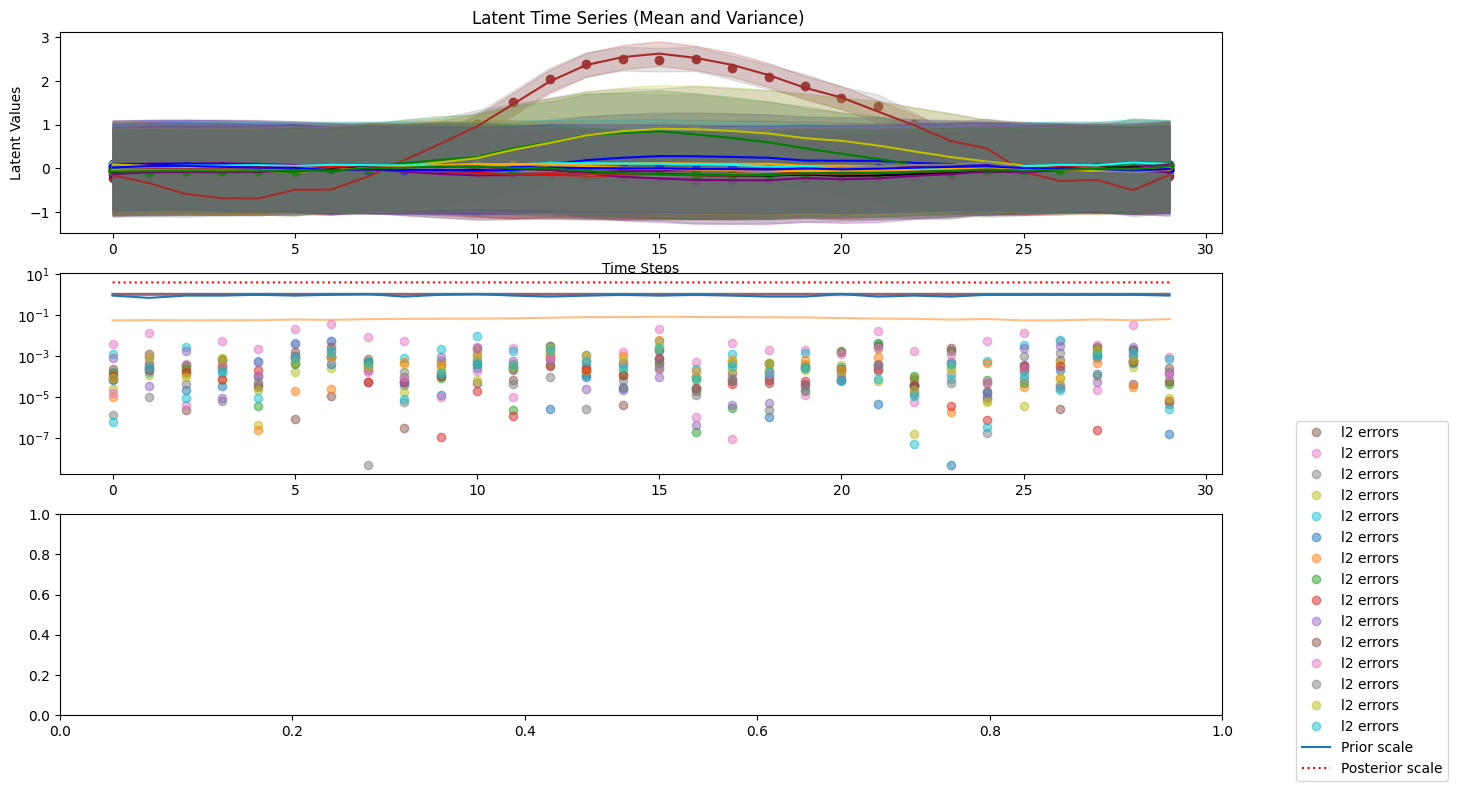

In [49]:
#gpvae.model.backbone.alpha = 1e1
#for i,param in enumerate(gpvae.model.backbone.decoder.parameters()):
    #if i!=0:
#    param.requires_grad = False
gpvae.fit(dataset_train)  # train the model on the dataset

In [63]:
#for i,param in enumerate(gpvae.model.backbone.decoder.parameters()):
#    if i!=0:
#        param.requires_grad = False
#for i,param in enumerate(gpvae.model.backbone.encoder.parameters()):
#    if i<=5:
#        param.requires_grad = False
gpvae.model.backbone.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)
gpvae.model.backbone.alpha = 1e0
gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

2025-01-22 10:19:34 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-01-22 10:19:34 [INFO]: Finished training. The best model is from epoch#1.


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

In [27]:
# save and load
import torch
torch.save(gpvae, f'gvpae_p_dataset_{p_dataset}-a_{gpvae.model.backbone.alpha}_b_{gpvae.model.backbone.beta}_gamma_{gpvae.model.backbone.gamma}')
gpvae = torch.load(f'gvpae_p_dataset_{p_dataset}-a_{gpvae.model.backbone.alpha}_b_{gpvae.model.backbone.beta}_gamma_{gpvae.model.backbone.gamma}')

PicklingError: Can't pickle <class 'pypots.nn.modules.gp_ae.backbone.BackboneGP_VAE'>: it's not the same object as pypots.nn.modules.gp_ae.backbone.BackboneGP_VAE

## Observe sampled reconstructions

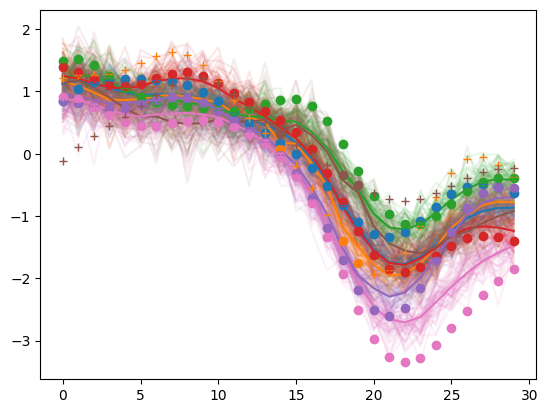

In [51]:
import torch

n_samples = 50
i = 11

qz_x = gpvae.model.backbone.encode(torch.tensor(X[:20]).float())
for _ in range(n_samples):
    z = qz_x.rsample()
    X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
    plt.plot(X_recon[i], label = 'reconstruction', alpha = .1)
    plt.gca().set_prop_cycle(None)
z = qz_x.mean
X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[i], label = 'mean reconstruction')
plt.gca().set_prop_cycle(None)
X_0 = np.copy(X[i])
X_0[X_0==0] = np.nan
plt.plot(X_0,'o', label = 'Input')
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i],'+', label = 'Input')
plt.show();

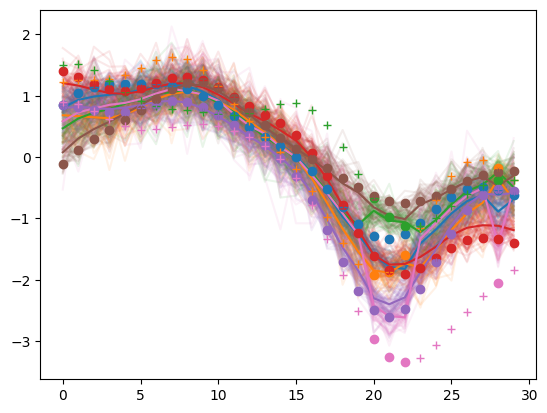

In [18]:
import torch

n_samples = 50
i = 11

qz_x = gpvae.model.backbone.encode(torch.tensor(X[:20]).float())
for _ in range(n_samples):
    z = qz_x.rsample()
    X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
    plt.plot(X_recon[i], label = 'reconstruction', alpha = .1)
    plt.gca().set_prop_cycle(None)
z = qz_x.mean
X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[i], label = 'mean reconstruction')
plt.gca().set_prop_cycle(None)
X_0 = np.copy(X[i])
X_0[X_0==0] = np.nan
plt.plot(X_0,'o', label = 'Input')
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i],'+', label = 'Input')
plt.show();

In [82]:
from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
#gpvae.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)
#gpvae.gp.p = 0.1 # ratio of imputation of the dataset
gpvae.fit_kernel(dataset_train)  # train the model to learn the kernel parameters

fitting kernel


Epoch 1/20: 55it [00:02, 25.62it/s]


Epoch 1/20: Average Loss = 0.044437


Epoch 2/20: 55it [00:02, 22.81it/s]


Epoch 2/20: Average Loss = 0.044907


...

Epoch 4/20: Average Loss = 0.044504


Epoch 5/20: 55it [00:02, 25.18it/s]


Epoch 5/20: Average Loss = 0.044909


Epoch 6/20: 40it [00:01, 23.67it/s]


KeyboardInterrupt: 

## Visualisation: embed the first 10 time series, use the GP scheme to correct, and plot reconstruction

In [83]:
X_torch = torch.tensor(X).float()[:20]
embedding = gpvae.model.backbone.encode(X_torch)
imputed_data = gpvae.gp.infer(embedding, X_torch)
X_recon = gpvae.model.backbone.decode(embedding.mean).mean

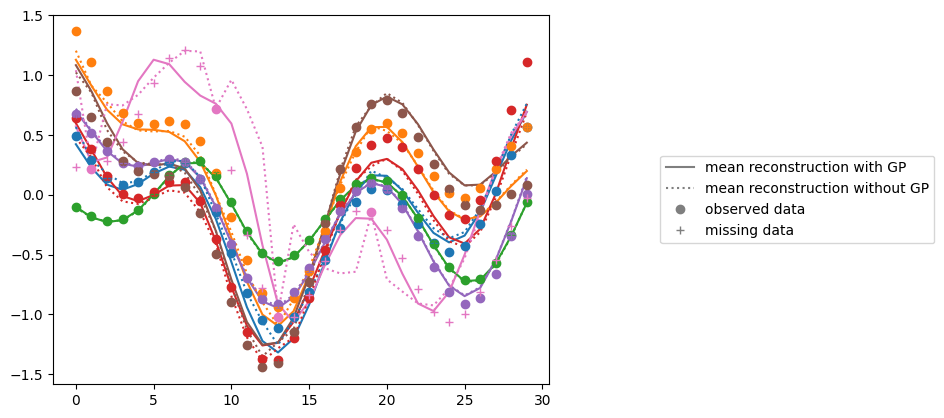

In [84]:
i = 11 ## reconstruct time series number i
X_torch[X_torch==0] = torch.nan
plt.plot(imputed_data[i].detach())
plt.plot([], label = 'mean reconstruction with GP')
plt.gca().set_prop_cycle(None)
plt.plot(X_recon[i].detach(), ':')
plt.plot([], ':', label = 'mean reconstruction without GP')
plt.gca().set_prop_cycle(None)
plt.plot(X_torch[i].detach(), 'o');
plt.plot([], 'o', label = 'observed data')
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i], '+');
plt.plot([], '+', label = 'missing data')
plt.legend(bbox_to_anchor=[1.5, 0.5], 
           loc='center')